### Imports and setup

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

c:\Users\willd\Dissertation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


### Load train/validation/test splits

In [2]:
project_root = Path("..").resolve()
split_dir = project_root / "data" / "processed" / "splits"
processed_dir = project_root / "data" / "processed"

train_df = pd.read_csv(split_dir / "train.csv")
val_df = pd.read_csv(split_dir / "val.csv")
test_df = pd.read_csv(split_dir / "test.csv")

target_cols = sorted([c for c in train_df.columns if c.startswith("y_")])
if not target_cols:
    raise ValueError("No target columns found (expected columns starting with 'y_').")

for df in (train_df, val_df, test_df):
    if "text_clean" not in df.columns:
        raise ValueError("Missing required column: text_clean")
    df["text_clean"] = df["text_clean"].fillna("").astype(str)

print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})
print("Labels:", len(target_cols))

{'train': 129, 'val': 27, 'test': 29}
Labels: 6


### Tokenize text and build datasets

In [3]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
MAX_LEN = 256

def encode_text(series):
    return tokenizer(
        series.tolist(),
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )

train_enc = encode_text(train_df["text_clean"])
val_enc = encode_text(val_df["text_clean"])
test_enc = encode_text(test_df["text_clean"])

train_labels = torch.tensor(train_df[target_cols].values, dtype=torch.float32)
val_labels = torch.tensor(val_df[target_cols].values, dtype=torch.float32)
test_labels = torch.tensor(test_df[target_cols].values, dtype=torch.float32)

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_ds = EmailDataset(train_enc, train_labels)
val_ds = EmailDataset(val_enc, val_labels)
test_ds = EmailDataset(test_enc, test_labels)

### Configure model and training process

In [4]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(target_cols),
    problem_type="multi_label_classification",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "precision_micro": precision_score(labels, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(labels, preds, average="micro", zero_division=0),
    }

# Per-label positive class weights for BCEWithLogitsLoss.
label_counts = train_df[target_cols].sum(axis=0).astype(float).values
num_samples = float(len(train_df))
pos_weight = (num_samples - label_counts) / np.clip(label_counts, 1.0, None)
pos_weight = torch.tensor(pos_weight, dtype=torch.float32)

class WeightedTrainer(Trainer):
    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight.to(logits.device))
        loss = loss_fct(logits, labels.float())
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir=str(project_root / "models" / "distilbert_multilabel_run"),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    seed=SEED,
    report_to="none",
    disable_tqdm=True,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    pos_weight=pos_weight,
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2213.21it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Train, evaluate, and save artifacts

In [5]:
train_output = trainer.train()
print(train_output)

val_metrics = trainer.evaluate(eval_dataset=val_ds)
test_metrics = trainer.evaluate(eval_dataset=test_ds)
print("Validation:", val_metrics)
print("Test:", test_metrics)

val_pred = trainer.predict(val_ds)
val_probs = 1 / (1 + np.exp(-val_pred.predictions))
val_true = val_pred.label_ids

threshold_grid = np.arange(0.15, 0.61, 0.05)
grid_scores = [
    f1_score(val_true, (val_probs >= t).astype(int), average="micro", zero_division=0)
    for t in threshold_grid
]
best_threshold = float(threshold_grid[int(np.argmax(grid_scores))])
print("Best global threshold (validation):", best_threshold)

val_preds_tuned = (val_probs >= best_threshold).astype(int)
print("Validation positive prediction rate:", float(val_preds_tuned.mean()))

test_pred = trainer.predict(test_ds)
test_probs = 1 / (1 + np.exp(-test_pred.predictions))
test_true = test_pred.label_ids
test_preds_tuned = (test_probs >= best_threshold).astype(int)
print("Test positive prediction rate:", float(test_preds_tuned.mean()))

test_tuned_metrics = {
    "f1_micro": f1_score(test_true, test_preds_tuned, average="micro", zero_division=0),
    "f1_macro": f1_score(test_true, test_preds_tuned, average="macro", zero_division=0),
    "precision_micro": precision_score(test_true, test_preds_tuned, average="micro", zero_division=0),
    "recall_micro": recall_score(test_true, test_preds_tuned, average="micro", zero_division=0),
}
print("Test tuned metrics:", test_tuned_metrics)

metrics_dir = processed_dir / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

split_metrics = pd.DataFrame([
    {k.replace("eval_", ""): float(v) for k, v in val_metrics.items() if k.startswith("eval_")},
    {k.replace("eval_", ""): float(v) for k, v in test_metrics.items() if k.startswith("eval_")},
])
split_metrics.insert(0, "split", ["validation", "test"])
split_metrics["threshold"] = best_threshold
split_metrics.to_csv(metrics_dir / "training_split_metrics.csv", index=False)

label_rows = []
for split_name, y_true, y_pred in [
    ("validation", val_true, val_preds_tuned),
    ("test", test_true, test_preds_tuned),
]:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        zero_division=0,
        average=None,
)
    label_rows.append(
        pd.DataFrame({
            "split": split_name,
            "label": [c.replace("y_", "") for c in target_cols],
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        })
    )

per_label_scores = pd.concat(label_rows, ignore_index=True)
per_label_scores.to_csv(metrics_dir / "training_per_label_scores.csv", index=False)

final_model_dir = project_root / "models" / "distilbert_multilabel"
final_model_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(final_model_dir))
tokenizer.save_pretrained(str(final_model_dir))

pd.DataFrame({
    "label": [c.replace("y_", "") for c in target_cols],
    "label_id": list(range(len(target_cols))),
}).to_csv(processed_dir / "label_taxonomy.csv", index=False)

pd.DataFrame({
    "label": [c.replace("y_", "") for c in target_cols],
    "label_id": list(range(len(target_cols))),
    "threshold": [best_threshold] * len(target_cols),
}).to_csv(processed_dir / "label_thresholds.csv", index=False)

print("Saved metrics to:", metrics_dir)
print("Saved model to:", final_model_dir)
print("Saved thresholds to:", processed_dir / "label_thresholds.csv")

c:\Users\willd\Dissertation\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '1.079', 'eval_f1_micro': '0.2796', 'eval_f1_macro': '0.1738', 'eval_precision_micro': '0.2097', 'eval_recall_micro': '0.4194', 'eval_runtime': '2.535', 'eval_samples_per_second': '10.65', 'eval_steps_per_second': '1.578', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]
c:\Users\willd\Dissertation\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '1.059', 'eval_f1_micro': '0.3838', 'eval_f1_macro': '0.4344', 'eval_precision_micro': '0.2794', 'eval_recall_micro': '0.6129', 'eval_runtime': '2.76', 'eval_samples_per_second': '9.783', 'eval_steps_per_second': '1.449', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]
c:\Users\willd\Dissertation\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Best global threshold (validation): 0.5500000000000002
Validation positive prediction rate: 0.16666666666666666


c:\Users\willd\Dissertation\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test positive prediction rate: 0.16666666666666666
Test tuned metrics: {'f1_micro': 0.6206896551724138, 'f1_macro': 0.6222222222222222, 'precision_micro': 0.6206896551724138, 'recall_micro': 0.6206896551724138}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.59it/s]

Saved metrics to: C:\Users\willd\Dissertation\data\processed\metrics
Saved model to: C:\Users\willd\Dissertation\models\distilbert_multilabel
Saved thresholds to: C:\Users\willd\Dissertation\data\processed\label_thresholds.csv


### Confusion matrix and per-label F1 (test)

Saved: C:\Users\willd\Dissertation\data\processed\metrics\training_per_label_f1.csv
Saved: C:\Users\willd\Dissertation\data\processed\metrics\training_confusion_matrix.csv
Saved: C:\Users\willd\Dissertation\data\processed\metrics\training_confusion_matrix.png


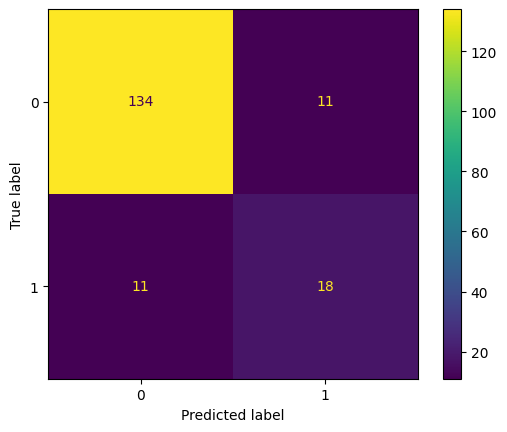

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_recall_fscore_support

metrics_dir = processed_dir / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

precision_t, recall_t, f1_t, support_t = precision_recall_fscore_support(
    test_true, test_preds_tuned, zero_division=0, average=None
)
test_f1_table = pd.DataFrame({
    "label": [c.replace("y_", "") for c in target_cols],
    "f1": f1_t,
    "precision": precision_t,
    "recall": recall_t,
    "support": support_t,
}).sort_values("f1", ascending=False)
test_f1_table.to_csv(metrics_dir / "training_per_label_f1.csv", index=False)

micro_cm = confusion_matrix(test_true.ravel(), test_preds_tuned.ravel())
pd.DataFrame(
    micro_cm,
    index=["actual_0", "actual_1"],
    columns=["pred_0", "pred_1"],
).to_csv(metrics_dir / "training_confusion_matrix.csv")

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(micro_cm, display_labels=["0", "1"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Test Confusion Matrix")
fig.tight_layout()
fig.savefig(metrics_dir / "training_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.close(fig)

print("Saved:", metrics_dir / "training_per_label_f1.csv")
print("Saved:", metrics_dir / "training_confusion_matrix.csv")
print("Saved:", metrics_dir / "training_confusion_matrix.png")